# 04 · Normlar ve Regularizasyonun Geometrisi
**Linear Algebra Lab** — Ridge/Lasso'nun Perde Arkası

---
> **Bu notebook'ta ne öğreneceğiz?**  
> "Ridge regresyon", "Lasso regresyon", "L1/L2 regularizasyon" — bu terimleri muhtemelen
> onlarca kere duydun, `sklearn.linear_model.Ridge()` yazdın, ama **NEDEN** Ridge katsayıları
> "küçültüyor" da Lasso "sıfırlıyor" sorusunun cevabını hiç görmedin. Bu notebook'u da,
> SVD/PCA notebook'u gibi, **çok yavaş ve hiçbir şeyi atlamadan** anlatacağım — çünkü bu
> kavram gerçekten HER YERDE karşına çıkıyor: `probability-lab` 08'de (MAP=Ridge) bunun
> olasılıksal tarafını görmüştük, burada GEOMETRİK tarafını (asıl "neden" sorusunun cevabını)
> göreceğiz.

**Önkoşul:** Vektör/Matris Temelleri (01), MLE/MAP (`probability-lab` 08 — Ridge=MAP bağlantısı)  
**Veri:**  
- `used_cars.csv` — 4009 ikinci el araba ilanı (fiyat, kilometre, motor gücü, vb.)  
- Sentetik regresyon verisi (`sklearn.datasets.make_regression`) — Lasso'nun "seyreklik" özelliğini net göstermek için  
**Araçlar:** Python (`numpy`, `sklearn.linear_model`, `matplotlib`)

---
## 1 · Norm Nedir? En Basit Haliyle: "Büyüklüğü Ölçmenin Farklı Yolları"

01'de bir vektörün "büyüklüğünü" (uzunluğunu) $\|\vec{v}\|=\sqrt{v_1^2+v_2^2}$ formülüyle
ölçmüştük. Ama bu, büyüklüğü ölçmenin **TEK YOLU DEĞİL** — sadece en tanıdık olanı.

**Basit bir şehir benzetmesi:** Bir şehirde A noktasından B noktasına gitmek istiyorsun.

- **Kuş uçuşu mesafe** (bir helikopterin uçacağı düz çizgi): bu, senin bildiğin **normal
  (Öklid) mesafe** — $\sqrt{(\Delta x)^2+(\Delta y)^2}$.
- **Yürüyerek gidilen mesafe** (sokaklar ızgara şeklindeyse, çapraz gidemezsin — önce
  sağa, sonra ileri gitmen gerekir): bu, **Manhattan mesafesi** — $|\Delta x|+|\Delta y|$.

Aynı iki nokta arasında, İKİ FARKLI "mesafe" sayısı elde ediyorsun — hangisini kullanacağın,
neyi ölçmek istediğine bağlı. **Norm**, işte bu "büyüklüğü/mesafeyi ölçme yöntemine" verilen
genel isim. Regularizasyonda kullandığımız iki norm, tam olarak bu iki mesafe kavramına
karşılık geliyor.

---
## 2 · L2 Norm (Öklid): Bildiğimiz Mesafe

$$\|\vec{v}\|_2 = \sqrt{v_1^2+v_2^2+\dots+v_n^2}$$

Bu, 01'de gördüğümüz "kuş uçuşu" mesafe. **Somut sayısal örnek:** $\vec{v}=[3,4]$ için:
$$\|\vec{v}\|_2 = \sqrt{3^2+4^2} = \sqrt{9+16} = \sqrt{25} = 5$$

(Bu, aslında ünlü "3-4-5 üçgeni" — bir dik üçgenin kenarları.)

---
## 3 · L1 Norm (Manhattan): "Sokakta Yürüme" Mesafesi

$$\|\vec{v}\|_1 = |v_1|+|v_2|+\dots+|v_n|$$

**Neden "Manhattan" deniyor?** New York'un Manhattan bölgesi, ızgara şeklinde sokaklardan
oluşuyor — çapraz gidemezsin, önce bir yönde sonra dik yönde yürürsün. Aynı $\vec{v}=[3,4]$
için:
$$\|\vec{v}\|_1 = |3|+|4| = 7$$

**Dikkat:** $L_1$ norm ($7$), $L_2$ norm'dan ($5$) her zaman **büyük veya eşit** çıkar —
çünkü "çapraz gidebilmek" (L2) her zaman "sadece dik yönlerde gidebilmekten" (L1) daha
kısa bir yoldur (üçgen eşitsizliği).

---
## 4 · Birim "Çemberler": Bu Notebook'un EN KRİTİK Fikri

**Soru:** "Merkeze olan mesafesi TAM OLARAK 1 olan tüm noktalar" hangi şekli oluşturur?

- **L2 normuna göre** ($\|\vec{v}\|_2=1$): Bu, senin bildiğin **GERÇEK bir daire**.
- **L1 normuna göre** ($\|\vec{v}\|_1=1$): Bu, köşeleri eksenler ÜZERİNDE olan bir
  **ELMAS (kare, 45° döndürülmüş)** şekli!

Bunu Python'da hemen çizip göreceğiz. Bu şekil farkı — biri YUVARLAK, diğeri KÖŞELİ —
Bölüm 8-9'da Ridge ile Lasso'nun NEDEN tamamen farklı davrandığının **tüm açıklamasının
temelini** oluşturuyor. Bu notebook'un geri kalanı, aslında bu tek görsel farkın
sonuçlarını takip etmekten ibaret.

---
## 5 · Neden Regularizasyona İhtiyacımız Var? (Çok Kısa Hatırlatma)

Bir regresyon modeli kurarken, elindeki veriye ÇOK SIKI uyum sağlayan (ama yeni veride kötü
performans gösteren) modeller kurabilirsin — buna **aşırı öğrenme (overfitting)** deniyor.
Bunun bir sebebi: bazı katsayılar aşırı BÜYÜK değerler alıp, verideki küçük gürültüleri bile
"gerçek bir örüntü" gibi ezberliyor.

**Regularizasyon fikri çok basit:** Modelin hata fonksiyonuna (loss), katsayıların
büyüklüğünü "cezalandıran" bir terim EKLEMEK — böylece model hem veriye uyum sağlamaya hem
de katsayılarını KÜÇÜK tutmaya zorlanıyor. Bu iki hedef arasındaki "denge", regularizasyonun
özü.

---
## 6 · Ridge Regresyon (L2 Regularizasyon)

$$\text{Loss}_{\text{Ridge}} = \underbrace{\sum_i(y_i-\hat{y}_i)^2}_{\text{normal hata}} + \underbrace{\alpha\sum_j \beta_j^2}_{\text{L2 CEZASI}}$$

Katsayıların KARELERİNİN toplamını cezalandırıyoruz. $\alpha$ (bazen $\lambda$ de yazılır),
bu cezanın ne kadar "sert" olduğunu kontrol eden bir kadran — $\alpha=0$ ise sıradan OLS
regresyonuna (03'teki `regression_diagnostics`'te gördüğümüz), $\alpha$ büyüdükçe
katsayılar giderek küçülür.

**HATIRLATMA (`probability-lab` 08'den):** Ridge, aslında katsayılar için bir **Gauss (Normal)
prior** varsayan bir MAP tahminiyle MATEMATİKSEL OLARAK AYNI ŞEY. Orada bunu sayısal olarak
kanıtlamıştık ($\alpha$ arttıkça katsayıların "büzüldüğünü" görmüştük) — burada NEDEN
büzüldüğünü GEOMETRİK olarak göreceğiz (Bölüm 8).

---
## 7 · Lasso Regresyon (L1 Regularizasyon)

$$\text{Loss}_{\text{Lasso}} = \underbrace{\sum_i(y_i-\hat{y}_i)^2}_{\text{normal hata}} + \underbrace{\alpha\sum_j |\beta_j|}_{\text{L1 CEZASI}}$$

Tek fark: katsayıların KARESİ yerine MUTLAK DEĞERİ cezalandırılıyor. Kulağa küçük bir fark
gibi geliyor ama SONUCU çok farklı: Lasso, gereksiz katsayıları TAM OLARAK SIFIRA
indiriyor (Ridge nadiren tam sıfıra iner) — bu yüzden Lasso aynı zamanda bir **özellik
seçimi (feature selection)** aracı olarak da kullanılıyor. Bunun matematiksel/geometrik
sebebini Bölüm 9'da göreceğiz.

**HATIRLATMA:** Lasso, katsayılar için bir **Laplace prior** varsayan MAP tahminine karşılık
geliyor (Laplace dağılımı, sıfır civarında sivri bir tepeye sahip — bu "sıfıra çekme"
eğilimini önceden yansıtıyor).

---
## 8 · GEOMETRİK AÇIKLAMA: Ridge Neden Küçültüyor ama Nadiren Sıfırlıyor?

Bu, notebook'un en önemli fikri — çok yavaş gidelim.

**Regularizasyonu farklı bir şekilde düşünelim:** "Loss'u minimize et + ceza ekle" yerine,
matematiksel olarak eşdeğer bir başka soru sorabiliriz: **"Katsayıların normu belirli bir
$t$ değerini AŞMASIN kısıtı altında, Loss'u minimize et."** ($\alpha$ büyüdükçe, buna
karşılık gelen $t$ küçülür — ikisi aynı fikrin farklı ifadeleri.)

**Şimdi görsel olarak düşün:**
1. Loss fonksiyonunun (katsayı uzayında) konturlarını çiz — bunlar İÇ İÇE ELİPSLER, en
   ortadaki nokta "kısıtsız" en iyi çözüm (OLS'in bulacağı nokta).
2. Kısıt bölgesini çiz — L2 için bu bir **DAİRE** (Bölüm 4'ten).
3. Kısıtlı çözüm, elipslerin dairenin sınırına İLK DOKUNDUĞU noktadır.

Bir dairenin sınırı **PÜRÜZSÜZ** (hiç köşesi yok) — bu yüzden elips, daireye HANGİ açıdan
yaklaşırsa yaklaşsın, dokunma noktası dairenin üzerinde HERHANGİ bir yerde olabilir. Bu
noktanın TAM OLARAK bir eksen üzerine (yani bir katsayının TAM SIFIR olduğu bir noktaya)
denk gelmesi, **istatistiksel olarak son derece nadir** bir tesadüf — sürekli bir çemberde
"tam ekseninde" olmak, sonsuz noktadan sadece 2 tanesi demek.

---
## 9 · GEOMETRİK AÇIKLAMA: Lasso Neden Katsayıları TAM SIFIRA İtiyor?

Şimdi AYNI senaryoyu, kısıt bölgesi bir **ELMAS** (L1) olduğunda düşünelim.

Bir elmasın (kare/baklava şeklinin) **KÖŞELERİ** var — ve bu köşeler TAM OLARAK eksenlerin
üzerinde duruyor (Bölüm 4'teki görseli hatırla). Elips, elmasa yaklaşırken:

- Elmasın DÜZ KENARINA dokunursa: normal bir tesadüf, iki katsayı da sıfırdan farklı kalır.
- Elmasın KÖŞESİNE dokunursa: bu köşe zaten bir eksen üzerinde olduğu için, **bir katsayı
  otomatik olarak TAM SIFIR** olur!

**Neden köşeye dokunma ihtimali bu kadar yüksek?** Çünkü köşeler, elmasın "en dışa çıkıntılı"
noktaları — çoğu yönden yaklaşan bir elips, önce bu çıkıntılı köşelere değme eğiliminde
(matematiksel olarak: köşelerde kısıt bölgesinin sınırı "keskin bir açı" yapıyor, ve
optimizasyon teorisinde keskin köşeler çözümü "çekme" eğiliminde). Bu yüzden Lasso, pratikte
SIK SIK bazı katsayıları tam sıfıra indiriyor — bu, Ridge'in ASLA yapmadığı bir şey.

Python bölümünde (özellikle Python 6) bu iki senaryoyu GERÇEKTEN çizip, kesişim noktalarını
göreceğiz — soyut kalmasın diye.

---
## 10 · Elastic Net: İkisinin Karışımı (Kısaca)

$$\text{Loss}_{\text{ElasticNet}} = \sum_i(y_i-\hat{y}_i)^2 + \alpha\underbrace{\left[\rho\sum_j|\beta_j| + (1-\rho)\sum_j\beta_j^2\right]}_{L1 ve L2 CEZALARI}$$

L1 ve L2 cezalarının AĞIRLIKLI ORTALAMASI ($\rho$ karışım oranı). Hem Lasso'nun "seyreklik"
özelliğinden hem Ridge'in "kararlılık" özelliğinden (birbiriyle çok ilişkili değişkenler
varken Lasso rastgele birini seçip diğerini sıfırlayabiliyor, bu bazen istenmez — Elastic
Net bunu yumuşatıyor) faydalanmak istediğinde kullanılıyor.

---
## 11 · Ne Zaman Hangisini Kullanmalı? Özet Karar Tablosu

| | Ridge (L2) | Lasso (L1) | Elastic Net |
|---|---|---|---|
| Katsayıları | Küçültür (nadiren sıfırlar) | SIFIRA indirir (özellik seçimi) | Karışık davranış |
| Ne zaman tercih edilir | TÜM özelliklerin biraz katkısı olduğunu düşünüyorsan | Çoğu özelliğin GEREKSİZ olduğunu düşünüyorsan | İkisinden de emin değilsen |
| Çok-korelasyonlu özelliklerde | Hepsini benzer şekilde küçültür (kararlı) | Rastgele birini seçip diğerini sıfırlar (kararsız olabilir) | Dengeler |
| Kapalı-form çözüm var mı? | Evet (08'de gördüğümüz formül) | Hayır (iteratif optimizasyon gerekir) | Hayır |

---
# 🐍 Python Uygulaması

7 adımda ilerleyeceğiz — teorideki her iddiayı somut olarak kanıtlayacağız:
1. **L1/L2 Norm Hesaplama** — Bölüm 2-3'teki sayısal örneği doğrulama
2. **Birim Çemberler: Elmas vs Daire** — Bölüm 4'ün görsel kanıtı
3. **Gerçek Veri Hazırlama** — used_cars.csv'yi temizleme
4. **Ridge Regularization Path** — α arttıkça katsayılar nasıl küçülüyor
5. **Lasso Regularization Path** — α arttıkça katsayılar nasıl SIFIRLANIYOR
6. **GEOMETRİK KANIT** — Loss konturu + kısıt bölgesi kesişimini gerçekten çizme
7. **Gerçek Veride Ridge vs Lasso** — Hangi özellikleri Lasso "elden çıkardı"?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 7)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 📏 Python 1 — L1/L2 Norm Hesaplama: Sayısal Doğrulama

**Ne yapıyoruz?**  
Bölüm 2-3'teki $\vec{v}=[3,4]$ örneğini (`L2=5`, `L1=7`) `numpy` ile doğruluyoruz.

In [2]:
v = np.array([3, 4])

L2_norm = np.linalg.norm(v, ord=2)  # veya sadece np.linalg.norm(v)
L1_norm = np.linalg.norm(v, ord=1)

print(f"v = {v}")
print(f"L2 norm (Öklid, 'kuş uçuşu'): {L2_norm}  (elle: 5)")
print(f"L1 norm (Manhattan, 'sokakta yürüme'): {L1_norm}  (elle: 7)")
print(f"\nL1 her zaman L2'den büyük/eşit mi? {'EVET ✓' if L1_norm >= L2_norm else 'HAYIR'}")

v = [3 4]
L2 norm (Öklid, 'kuş uçuşu'): 5.0  (elle: 5)
L1 norm (Manhattan, 'sokakta yürüme'): 7.0  (elle: 7)

L1 her zaman L2'den büyük/eşit mi? EVET ✓


---
### 💎 Python 2 — Birim Çemberler: Elmas vs Daire (KRİTİK GÖRSEL)

**Ne yapıyoruz?**  
Bölüm 4'teki iddiayı çiziyoruz: "merkeze L2 mesafesi 1 olan noktalar" ve "merkeze L1
mesafesi 1 olan noktalar" gerçekten farklı şekiller mi oluşturuyor?

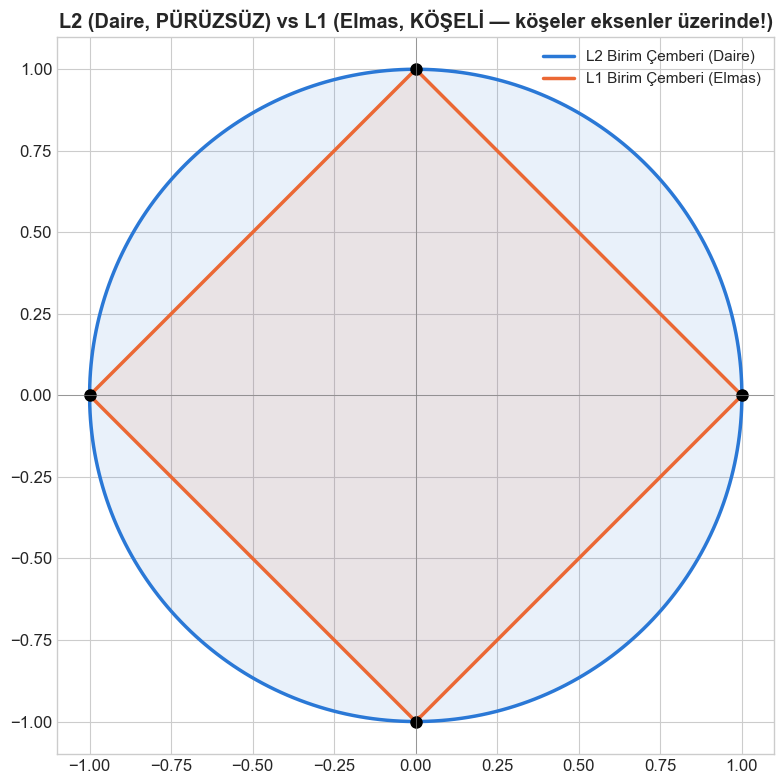

YORUM: Siyah noktalar elmasın 4 köşesi - hepsi TAM OLARAK bir eksenin üzerinde
duruyor ((1,0), (-1,0), (0,1), (0,-1)). Bölüm 9'da bu köşelerin neden Lasso'nun
katsayıları sıfırlamasının anahtarı olduğunu göreceğiz.


In [3]:
aci = np.linspace(0, 2*np.pi, 300)

# L2 birim cemberi: x^2+y^2=1 -> standart parametrik cember denklemi
l2_x, l2_y = np.cos(aci), np.sin(aci)

# L1 birim "cemberi" (elmas): |x|+|y|=1 -> parametrik olarak once cember uretip
# sonra HER NOKTAYI kendi L1 normuna bolerek L1=1 yuzeyine tasiyoruz
rastgele_x, rastgele_y = np.cos(aci), np.sin(aci)
l1_normlari = np.abs(rastgele_x) + np.abs(rastgele_y)
l1_x, l1_y = rastgele_x / l1_normlari, rastgele_y / l1_normlari

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(l2_x, l2_y, color='#2a78d6', linewidth=2.5, label='L2 Birim Çemberi (Daire)')
ax.plot(l1_x, l1_y, color='#eb6834', linewidth=2.5, label='L1 Birim Çemberi (Elmas)')
ax.fill(l2_x, l2_y, color='#2a78d6', alpha=0.1)
ax.fill(l1_x, l1_y, color='#eb6834', alpha=0.1)

# Eksenler uzerindeki kritik koseleri isaretleyelim (elmasin koseleri TAM burada)
for nokta in [(1,0), (-1,0), (0,1), (0,-1)]:
    ax.plot(*nokta, 'ko', markersize=8)

ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
ax.set_aspect('equal')
ax.legend(fontsize=11, loc='upper right')
ax.set_title('L2 (Daire, PÜRÜZSÜZ) vs L1 (Elmas, KÖŞELİ — köşeler eksenler üzerinde!)', fontweight='bold')
plt.tight_layout()
plt.show()

print("YORUM: Siyah noktalar elmasın 4 köşesi - hepsi TAM OLARAK bir eksenin üzerinde")
print("duruyor ((1,0), (-1,0), (0,1), (0,-1)). Bölüm 9'da bu köşelerin neden Lasso'nun")
print("katsayıları sıfırlamasının anahtarı olduğunu göreceğiz.")

---
### 🚗 Python 3 — Gerçek Veri Hazırlama: `used_cars.csv`'yi Temizleme

**Ne yapıyoruz?**  
Bu veri seti "ham" haliyle geliyor — fiyat `"$10,300"` gibi metin, kilometre `"51,000 mi."`
gibi metin, motor gücü ise `"300.0HP 3.7L V6..."` gibi serbest metin içinde SAKLI. Sayısal
analiz yapabilmemiz için önce bunları TEMİZ sayılara çevireceğiz.

In [4]:
import re

arabalar = pd.read_csv('data/used_cars.csv')
print(f"Ham veri: {arabalar.shape[0]} ilan, {arabalar.shape[1]} sütun")
print(arabalar[['price', 'milage', 'engine']].head(3))

# 1) Fiyat: "$10,300" -> 10300.0
arabalar['fiyat'] = (arabalar['price'].str.replace('$', '', regex=False)
                                        .str.replace(',', '', regex=False)
                                        .astype(float))

# 2) Kilometre: "51,000 mi." -> 51000.0
arabalar['kilometre'] = (arabalar['milage'].str.replace(' mi.', '', regex=False)
                                             .str.replace(',', '', regex=False)
                                             .astype(float))

# 3) Arac yasi: model yilindan hesapla
arabalar['arac_yasi'] = 2026 - arabalar['model_year']

# 4) Motor gucunu (HP) ve motor hacmini (Litre) serbest metinden REGEX ile cikar
def hp_cikar(engine_str):
    eslesme = re.search(r'(\d+\.?\d*)HP', str(engine_str))
    return float(eslesme.group(1)) if eslesme else np.nan

def litre_cikar(engine_str):
    eslesme = re.search(r'(\d+\.?\d*)L\b', str(engine_str))
    return float(eslesme.group(1)) if eslesme else np.nan

arabalar['beygir_gucu'] = arabalar['engine'].apply(hp_cikar)
arabalar['motor_litre'] = arabalar['engine'].apply(litre_cikar)

print("\nTemizlenmiş örnek satırlar:")
print(arabalar[['fiyat', 'kilometre', 'arac_yasi', 'beygir_gucu', 'motor_litre']].head(5))

# Eksik degerleri (regex her satirda eslesme bulamayabilir) cikaralim, asiri pahali/ucuz
# ilanlari da (muhtemelen veri hatasi/lüks nadir araclar) kirpalim
ozellikler = ['kilometre', 'arac_yasi', 'beygir_gucu', 'motor_litre']
arabalar_temiz = arabalar.dropna(subset=ozellikler + ['fiyat']).copy()
arabalar_temiz = arabalar_temiz[
    (arabalar_temiz['fiyat'] > 2000) & (arabalar_temiz['fiyat'] < arabalar_temiz['fiyat'].quantile(0.98))
]

print(f"\nTemizlik sonrası: {arabalar_temiz.shape[0]} ilan kullanılabilir durumda")
print(f"\nÖzellikler arası korelasyon (multicollinearity kontrolü):")
print(arabalar_temiz[['fiyat'] + ozellikler].corr().round(3))

print("\nYORUM: beygir_gucu ile motor_litre arasında belirgin bir korelasyon var (motor")
print("ne kadar büyükse genelde o kadar güçlü) - bu, Ridge/Lasso'nun 'multicollinearity'i")
print("nasıl ele aldığını göstermek için TAM İSTEDİĞİMİZ senaryo (03'teki Auto MPG VIF")
print("konusuyla aynı aile).")

Ham veri: 4009 ilan, 12 sütun
     price      milage                                             engine
0  $10,300  51,000 mi.  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...
1  $38,005  34,742 mi.                               3.8L V6 24V GDI DOHC
2  $54,598  22,372 mi.                                     3.5 Liter DOHC

Temizlenmiş örnek satırlar:
     fiyat  kilometre  arac_yasi  beygir_gucu  motor_litre
0  10300.0    51000.0         13        300.0          3.7
1  38005.0    34742.0          5          NaN          3.8
2  54598.0    22372.0          4          NaN          NaN
3  15500.0    88900.0         11        354.0          3.5
4  34999.0     9835.0          5          NaN          2.0

Temizlik sonrası: 3006 ilan kullanılabilir durumda

Özellikler arası korelasyon (multicollinearity kontrolü):
             fiyat  kilometre  arac_yasi  beygir_gucu  motor_litre
fiyat        1.000     -0.606     -0.557        0.636        0.242
kilometre   -0.606      1.000      0.573      

---
### 📉 Python 4 — Ridge Regularization Path: α Arttıkça Katsayılar Nasıl Küçülüyor?

**Ne yapıyoruz?**  
`used_cars` verisinde `fiyat`'ı 4 özellikten tahmin eden bir Ridge modeli kuruyoruz, $\alpha$'yı
0'dan çok büyük bir sayıya kadar artırıp her seferinde katsayıların nasıl değiştiğini
çiziyoruz — buna **"regularization path"** deniyor.

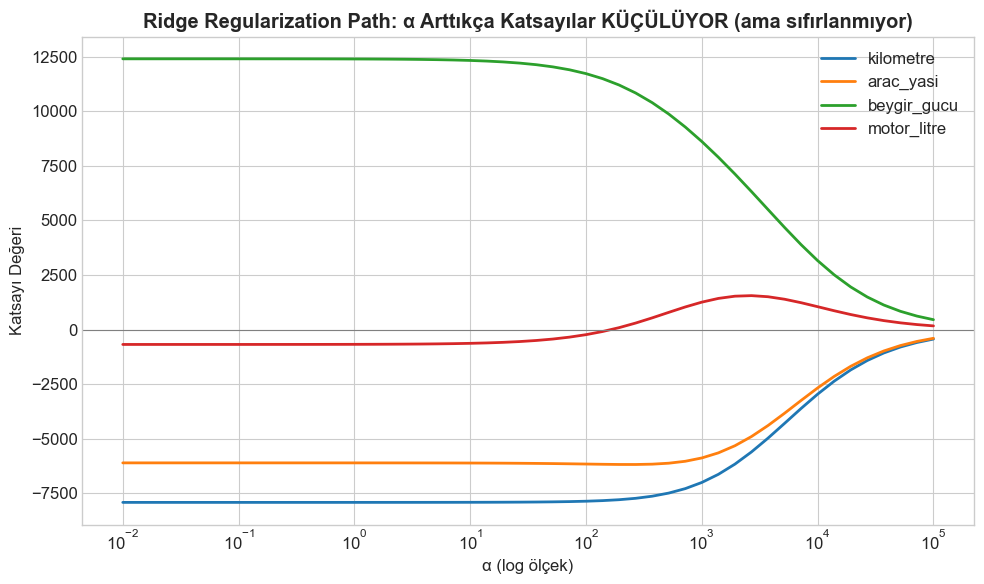

YORUM: Tüm çizgiler sıfıra doğru YAKLAŞIYOR ama HİÇBİRİ tam sıfıra İNMİYOR -
en yüksek α'da bile (grafiğin en sağında) katsayılar hala (çok küçük de olsa)
sıfırdan farklı. Bu, Bölüm 8'deki 'dairenin pürüzsüz sınırı' açıklamasının
sayısal kanıtı.


In [5]:
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler

X = arabalar_temiz[ozellikler].values
y = arabalar_temiz['fiyat'].values

# Regularizasyon oncesi HER ZAMAN standartlastir (03'teki PCA dersini hatirla!)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

alpha_degerleri = np.logspace(-2, 5, 50)
ridge_katsayilari = []

for a in alpha_degerleri:
    ridge = Ridge(alpha=a)
    ridge.fit(X_std, y)
    ridge_katsayilari.append(ridge.coef_)

ridge_katsayilari = np.array(ridge_katsayilari)

fig, ax = plt.subplots(figsize=(10, 6))
for i, ozellik in enumerate(ozellikler):
    ax.plot(alpha_degerleri, ridge_katsayilari[:, i], linewidth=2, label=ozellik)
ax.set_xscale('log')
ax.set_xlabel('α (log ölçek)')
ax.set_ylabel('Katsayı Değeri')
ax.set_title('Ridge Regularization Path: α Arttıkça Katsayılar KÜÇÜLÜYOR (ama sıfırlanmıyor)', fontweight='bold')
ax.axhline(0, color='gray', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

print("YORUM: Tüm çizgiler sıfıra doğru YAKLAŞIYOR ama HİÇBİRİ tam sıfıra İNMİYOR -")
print("en yüksek α'da bile (grafiğin en sağında) katsayılar hala (çok küçük de olsa)")
print("sıfırdan farklı. Bu, Bölüm 8'deki 'dairenin pürüzsüz sınırı' açıklamasının")
print("sayısal kanıtı.")

---
### 📉 Python 5 — Lasso Regularization Path: α Arttıkça Katsayılar SIFIRLANIYOR

**Ne yapıyoruz?**  
Python 4'ün BİREBİR AYNISI, ama bu sefer `Ridge` yerine `Lasso` kullanıyoruz. Fark
gözünle görülecek kadar net olacak.

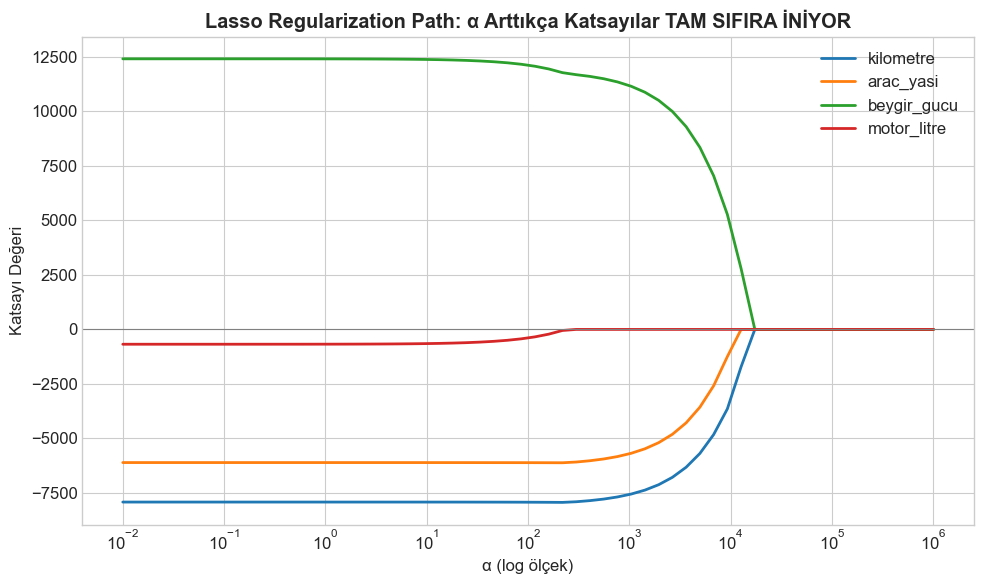

Her özelliğin TAM SIFIRA indiği α değeri:
  kilometre: α≈17269.83'de sıfırlanıyor
  arac_yasi: α≈12638.48'de sıfırlanıyor
  beygir_gucu: α≈17269.83'de sıfırlanıyor
  motor_litre: α≈298.25'de sıfırlanıyor

YORUM: Ridge grafiğinden FARKLI olarak, buradaki çizgiler TEKER TEKER sıfıra
ÇARPIYOR (yumuşakça yaklaşmıyor, aniden sıfır oluyor) - bu tam olarak Bölüm 9'daki
'köşeye değme' davranışının sayısal kanıtı.


In [6]:
alpha_degerleri_lasso = np.logspace(-2, 6, 60)  # genis araliktan daha net bir 'sifirlanma sirasi' gormek icin
lasso_katsayilari = []

for a in alpha_degerleri_lasso:
    lasso = Lasso(alpha=a, max_iter=20000)
    lasso.fit(X_std, y)
    lasso_katsayilari.append(lasso.coef_)

lasso_katsayilari = np.array(lasso_katsayilari)

fig, ax = plt.subplots(figsize=(10, 6))
for i, ozellik in enumerate(ozellikler):
    ax.plot(alpha_degerleri_lasso, lasso_katsayilari[:, i], linewidth=2, label=ozellik)
ax.set_xscale('log')
ax.set_xlabel('α (log ölçek)')
ax.set_ylabel('Katsayı Değeri')
ax.set_title('Lasso Regularization Path: α Arttıkça Katsayılar TAM SIFIRA İNİYOR', fontweight='bold')
ax.axhline(0, color='gray', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

# Hangi alpha'da hangi ozellik sifirlaniyor, tek tek gosterelim
print("Her özelliğin TAM SIFIRA indiği α değeri:")
for i, ozellik in enumerate(ozellikler):
    sifirlandigi_index = np.where(np.abs(lasso_katsayilari[:, i]) < 1e-6)[0]
    if len(sifirlandigi_index) > 0:
        ilk_sifir_alpha = alpha_degerleri_lasso[sifirlandigi_index[0]]
        print(f"  {ozellik}: α≈{ilk_sifir_alpha:.2f}'de sıfırlanıyor")
    else:
        print(f"  {ozellik}: test edilen aralıkta hiç sıfırlanmadı")

print("\nYORUM: Ridge grafiğinden FARKLI olarak, buradaki çizgiler TEKER TEKER sıfıra")
print("ÇARPIYOR (yumuşakça yaklaşmıyor, aniden sıfır oluyor) - bu tam olarak Bölüm 9'daki")
print("'köşeye değme' davranışının sayısal kanıtı.")

---
### 🎯 Python 6 — GEOMETRİK KANIT: Loss Konturu + Kısıt Bölgesi Kesişimi

**Ne yapıyoruz?**  
Bölüm 8-9'daki iddiayı GERÇEKTEN çiziyoruz — bu, notebook'un en önemli görseli. İki
özellikli basit bir regresyon problemi kuracağız (görebilmek için sadece 2 boyut), OLS
çözümünü bulacağız, sonra Ridge'in DAİRE kısıtıyla, Lasso'nun ELMAS kısıtıyla nereye
"çekildiğini" TAM OLARAK göreceğiz.

OLS çözümü (kısıtsız 'en iyi' nokta): β1=3.191, β2=1.757
Ridge çözümü: β1=2.996, β2=1.811
Lasso çözümü: β1=2.467, β2=0.000  <- β2 TAM SIFIR!


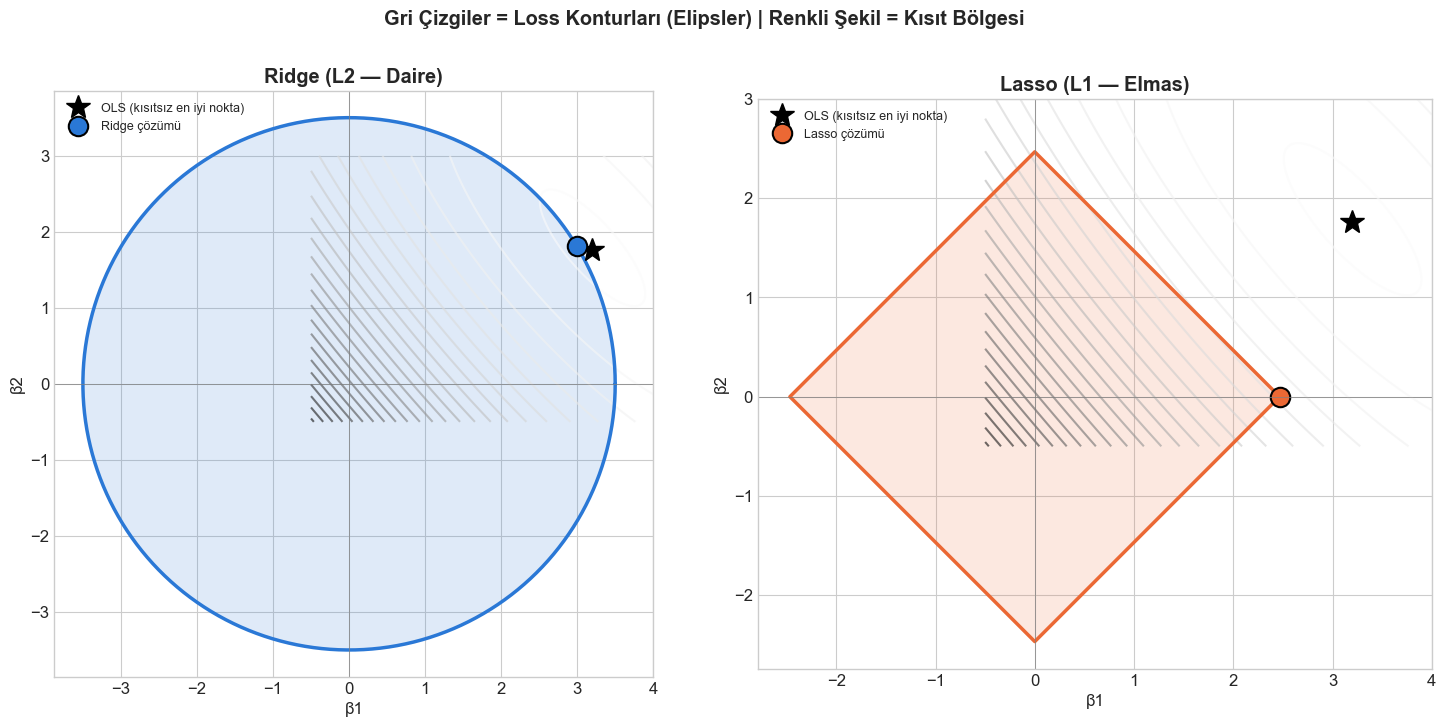


YORUM: SOLDA (Ridge), mavi nokta (çözüm) dairenin sınırında HERHANGİ bir yerde -
iki eksende de sıfırdan uzak. SAĞDA (Lasso), turuncu nokta TAM OLARAK elmasın
bir KÖŞESİNDE - ve bu köşe β2 EKSENİ üzerinde değil, β1 EKSENİ üzerinde duruyor,
yani β2=0! Bu, Bölüm 9'da anlattığımız 'köşeye değme = bir katsayının sıfırlanması'
iddiasının TAM OLARAK gözle görülür kanıtı.


In [7]:
# Basit, 2 ozellikli, KASITLI olarak iliskili (multicollinear) sentetik veri
rng = np.random.default_rng(7)
n = 200
X1 = rng.normal(0, 1, n)
X2 = 0.7 * X1 + rng.normal(0, 0.5, n)  # X2, X1 ile iliskili
y_sentetik = 3 * X1 + 2 * X2 + rng.normal(0, 1, n)
X_sentetik = np.column_stack([X1, X2])

ols_2d = LinearRegression().fit(X_sentetik, y_sentetik)
print(f"OLS çözümü (kısıtsız 'en iyi' nokta): β1={ols_2d.coef_[0]:.3f}, β2={ols_2d.coef_[1]:.3f}")

# Ridge ve Lasso'yu, Lasso'nun BIR katsayiyi TAM SIFIRLADIGI bir alpha ile kosalim
ridge_2d = Ridge(alpha=8).fit(X_sentetik, y_sentetik)
lasso_2d = Lasso(alpha=1.5).fit(X_sentetik, y_sentetik)

print(f"Ridge çözümü: β1={ridge_2d.coef_[0]:.3f}, β2={ridge_2d.coef_[1]:.3f}")
print(f"Lasso çözümü: β1={lasso_2d.coef_[0]:.3f}, β2={lasso_2d.coef_[1]:.3f}  <- β2 TAM SIFIR!")

# Loss yuzeyini (kontur) hesaplamak icin bir izgara kuralim
b1_araligi = np.linspace(-0.5, 4, 200)
b2_araligi = np.linspace(-0.5, 3, 200)
B1, B2 = np.meshgrid(b1_araligi, b2_araligi)

Loss = np.zeros_like(B1)
for i in range(B1.shape[0]):
    for j in range(B1.shape[1]):
        tahmin = B1[i,j]*X1 + B2[i,j]*X2
        Loss[i,j] = np.sum((y_sentetik - tahmin)**2)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, kisit_turu, cozum, renk in zip(
    axes, ['Ridge (L2 — Daire)', 'Lasso (L1 — Elmas)'],
    [ridge_2d.coef_, lasso_2d.coef_], ['#2a78d6', '#eb6834']
):
    ax.contour(B1, B2, Loss, levels=25, cmap='Greys', alpha=0.6)

    if 'Ridge' in kisit_turu:
        yaricap = np.linalg.norm(cozum)
        aci = np.linspace(0, 2*np.pi, 200)
        ax.plot(yaricap*np.cos(aci), yaricap*np.sin(aci), color=renk, linewidth=2.5)
        ax.fill(yaricap*np.cos(aci), yaricap*np.sin(aci), color=renk, alpha=0.15)
    else:
        t = np.abs(cozum).sum()
        elmas_x = [t, 0, -t, 0, t]
        elmas_y = [0, t, 0, -t, 0]
        ax.plot(elmas_x, elmas_y, color=renk, linewidth=2.5)
        ax.fill(elmas_x, elmas_y, color=renk, alpha=0.15)

    ax.plot(*ols_2d.coef_, 'k*', markersize=18, label='OLS (kısıtsız en iyi nokta)')
    ax.plot(*cozum, 'o', color=renk, markersize=14, markeredgecolor='black',
            markeredgewidth=1.5, label=f'{kisit_turu.split(" ")[0]} çözümü')
    ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('β1'); ax.set_ylabel('β2')
    ax.set_title(kisit_turu, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_aspect('equal')

plt.suptitle('Gri Çizgiler = Loss Konturları (Elipsler) | Renkli Şekil = Kısıt Bölgesi', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nYORUM: SOLDA (Ridge), mavi nokta (çözüm) dairenin sınırında HERHANGİ bir yerde -")
print("iki eksende de sıfırdan uzak. SAĞDA (Lasso), turuncu nokta TAM OLARAK elmasın")
print("bir KÖŞESİNDE - ve bu köşe β2 EKSENİ üzerinde değil, β1 EKSENİ üzerinde duruyor,")
print("yani β2=0! Bu, Bölüm 9'da anlattığımız 'köşeye değme = bir katsayının sıfırlanması'")
print("iddiasının TAM OLARAK gözle görülür kanıtı.")

---
### ⚖️ Python 7 — Gerçek Veride Ridge vs Lasso: Hangi Özellikleri Lasso "Elden Çıkardı"?

**Ne yapıyoruz?**  
Sabit, makul bir $\alpha$ ile (regularization path'in "ortasından" bir nokta) Ridge ve
Lasso'yu SON KEZ karşılaştırıp, sade OLS ile birlikte üçünü yan yana bir tabloda görelim.

    Özellik  OLS (α=0)  Ridge (α=10)  Lasso (α=500)
  kilometre   -7913.69      -7909.55       -7804.13
  arac_yasi   -6103.52      -6110.72       -5969.76
beygir_gucu   12403.98      12329.40       11532.21
motor_litre    -679.20       -628.36          -0.00

Lasso'nun bu α'da SIFIRLADIĞI özellik(ler): ['motor_litre']


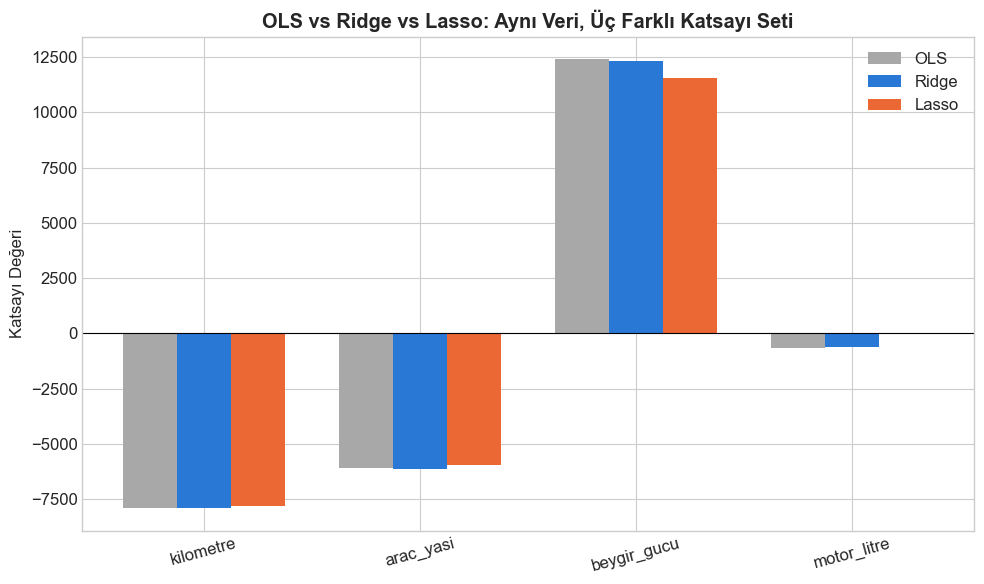


YORUM: OLS (gri) katsayıları 'ham' - hiç düzenlenmemiş. Ridge (mavi) hepsini
hafifçe küçültüyor ama HİÇBİRİNİ sıfırlamıyor. Lasso (turuncu) bazı çubukları
SIFIRA indirmiş olabilir - bu, Lasso'nun aynı zamanda bir 'otomatik özellik
seçici' olarak çalıştığının, gerçek bir veri setinde son kanıtı.


In [8]:
ols_final = LinearRegression().fit(X_std, y)
ridge_final = Ridge(alpha=10).fit(X_std, y)
lasso_final = Lasso(alpha=500, max_iter=20000).fit(X_std, y)

karsilastirma = pd.DataFrame({
    'Özellik': ozellikler,
    'OLS (α=0)': ols_final.coef_,
    'Ridge (α=10)': ridge_final.coef_,
    'Lasso (α=500)': lasso_final.coef_
})
print(karsilastirma.round(2).to_string(index=False))

sifirlanan = karsilastirma[np.isclose(karsilastirma['Lasso (α=500)'], 0)]['Özellik'].tolist()
print(f"\nLasso'nun bu α'da SIFIRLADIĞI özellik(ler): {sifirlanan if sifirlanan else 'Henüz yok'}")

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(ozellikler))
genislik = 0.25
ax.bar(x_pos - genislik, ols_final.coef_, genislik, label='OLS', color='#a8a8a8')
ax.bar(x_pos, ridge_final.coef_, genislik, label='Ridge', color='#2a78d6')
ax.bar(x_pos + genislik, lasso_final.coef_, genislik, label='Lasso', color='#eb6834')
ax.set_xticks(x_pos); ax.set_xticklabels(ozellikler, rotation=15)
ax.set_ylabel('Katsayı Değeri')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('OLS vs Ridge vs Lasso: Aynı Veri, Üç Farklı Katsayı Seti', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: OLS (gri) katsayıları 'ham' - hiç düzenlenmemiş. Ridge (mavi) hepsini")
print("hafifçe küçültüyor ama HİÇBİRİNİ sıfırlamıyor. Lasso (turuncu) bazı çubukları")
print("SIFIRA indirmiş olabilir - bu, Lasso'nun aynı zamanda bir 'otomatik özellik")
print("seçici' olarak çalıştığının, gerçek bir veri setinde son kanıtı.")

---
## ✏️ Egzersizler

---

### **E1.**
$\vec{v}=[6,-8]$ için L1 ve L2 normlarını elle hesapla (Bölüm 2-3'teki formülleri
kullanarak), `numpy` ile doğrula.

In [9]:
print("\n ==== Egzersiz 1: L1/L2 Norm Hesabı ====")
v = np.array([6, -8])

L2_norm = np.linalg.norm(v, ord=2)
L1_norm = np.linalg.norm(v, ord=1)

print(f"v = {v}")
print(f"L2 norm (Öklid, 'kuş uçuşu'): {L2_norm}  (elle: 10)")
print(f"L1 norm (Manhattan, 'sokakta yürüme'): {L1_norm}  (elle: 14)")


 ==== Egzersiz 1: L1/L2 Norm Hesabı ====
v = [ 6 -8]
L2 norm (Öklid, 'kuş uçuşu'): 10.0  (elle: 10)
L1 norm (Manhattan, 'sokakta yürüme'): 14.0  (elle: 14)


---

### **E2.**
Python 2'deki elmas/daire görselini, "L3 norm" ($\|\vec{v}\|_3=(|v_1|^3+|v_2|^3)^{1/3}$)
için de çiz — şekli L1 (elmas) ile L2 (daire) arasında bir yerde mi çıkıyor?


 ==== Egzersiz 2: L3 Norm Gösterimi ====


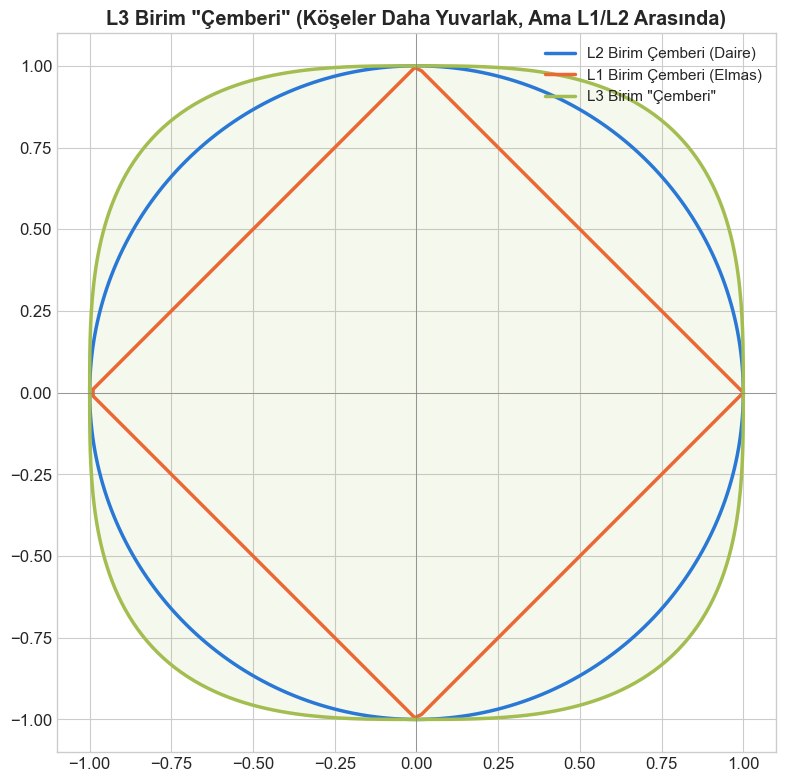

In [11]:
print("\n ==== Egzersiz 2: L3 Norm Gösterimi ====")

aci = np.linspace(0, 2*np.pi, 300)
rastgele_x, rastgele_y = np.cos(aci), np.sin(aci)
l3_normlari = (np.abs(rastgele_x)**3 + np.abs(rastgele_y)**3)**(1/3)
l3_x, l3_y = rastgele_x / l3_normlari, rastgele_y / l3_normlari


fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(l2_x, l2_y, color='#2a78d6', linewidth=2.5, label='L2 Birim Çemberi (Daire)')
ax.plot(l1_x, l1_y, color='#eb6834', linewidth=2.5, label='L1 Birim Çemberi (Elmas)')
ax.plot(l3_x, l3_y, color="#a4bd51", linewidth=2.5, label='L3 Birim "Çemberi"')
ax.fill(l3_x, l3_y, color='#a4bd51', alpha=0.1)
ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
ax.set_aspect('equal')
ax.legend(fontsize=11, loc='upper right')
ax.set_title('L3 Birim "Çemberi" (Köşeler Daha Yuvarlak, Ama L1/L2 Arasında)', fontweight='bold')
plt.tight_layout()
plt.show()

---

### **E3.**
`used_cars.csv`'de `brand` sütununu one-hot encoding ile sayısal hale getirip
(örn. `pd.get_dummies`) modele ekle — bu, çok sayıda yeni (çoğu gereksiz) özellik
yaratacak. Lasso'nun bu markaların çoğunu nasıl "elediğini" gözlemle — bu, Lasso'nun
gerçek dünyada NEDEN "özellik seçimi" için popüler olduğunun somut bir örneği.



 ==== Egzersiz 3: One-Hot Encoding ve Lasso ====
['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price', 'fiyat', 'kilometre', 'arac_yasi', 'beygir_gucu', 'motor_litre', 'marka_alfa', 'marka_aston', 'marka_audi', 'marka_bentley', 'marka_bmw', 'marka_buick', 'marka_cadillac', 'marka_chevrolet', 'marka_chrysler', 'marka_dodge', 'marka_ferrari', 'marka_fiat', 'marka_ford', 'marka_genesis', 'marka_gmc', 'marka_honda', 'marka_hummer', 'marka_hyundai', 'marka_infiniti', 'marka_jaguar', 'marka_jeep', 'marka_karma', 'marka_kia', 'marka_lamborghini', 'marka_land', 'marka_lexus', 'marka_lincoln', 'marka_lotus', 'marka_maserati', 'marka_maybach', 'marka_mazda', 'marka_mclaren', 'marka_mercedes-benz', 'marka_mercury', 'marka_mini', 'marka_mitsubishi', 'marka_nissan', 'marka_plymouth', 'marka_pontiac', 'marka_porsche', 'marka_ram', 'marka_rolls-royce', 'marka_saab', 'marka_saturn', 'marka_scion', 'marka_smart', 'ma

/var/folders/06/61zr6n0n0rs4fbl42p7szkfm0000gn/T/ipykernel_22635/3474953040.py:52: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


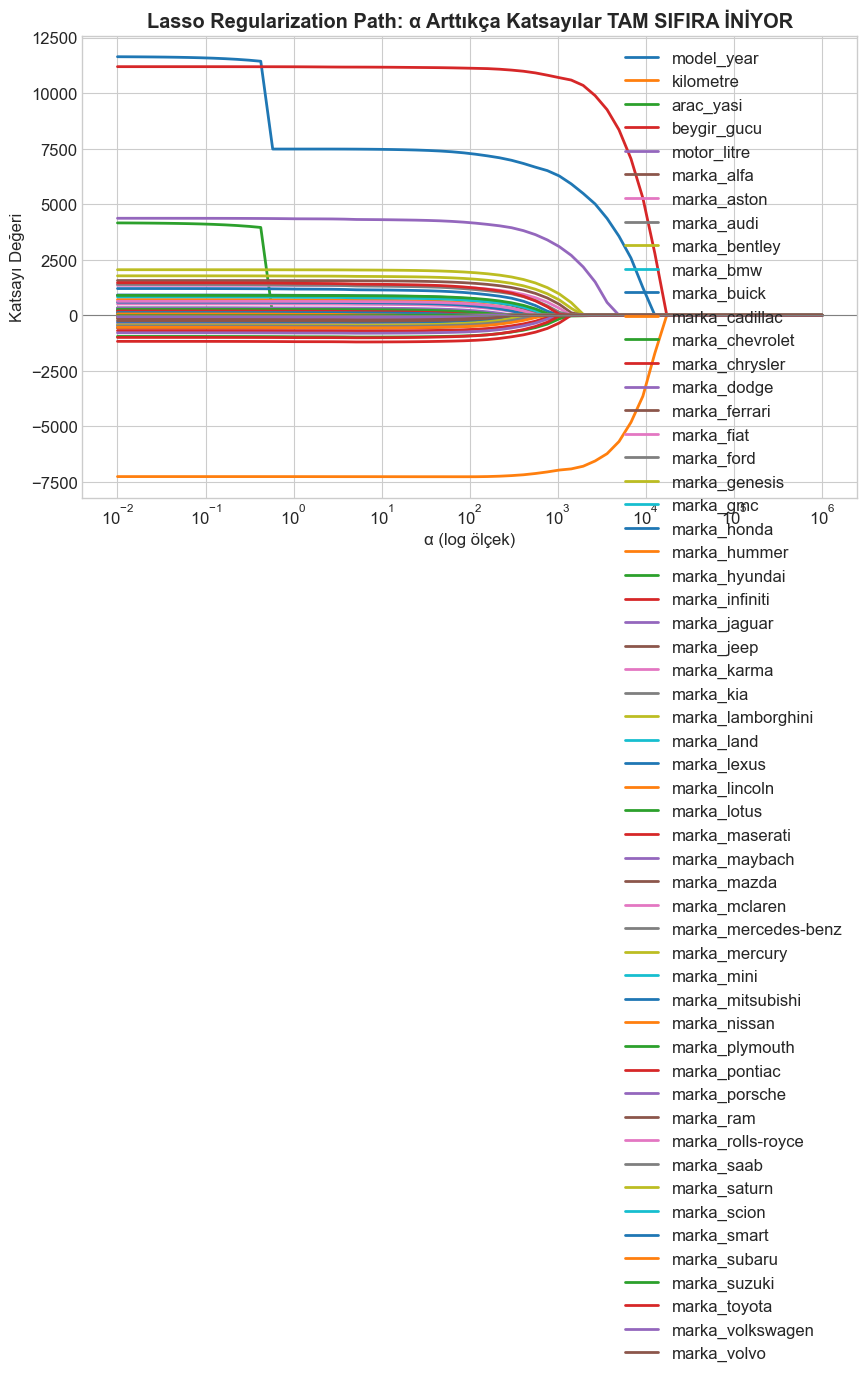

Her özelliğin TAM SIFIRA indiği α değeri:
  model_year: α≈12638.48'de sıfırlanıyor
  kilometre: α≈17269.83'de sıfırlanıyor
  arac_yasi: α≈12638.48'de sıfırlanıyor
  beygir_gucu: α≈17269.83'de sıfırlanıyor
  motor_litre: α≈3.77'de sıfırlanıyor
  marka_alfa: α≈760.95'de sıfırlanıyor
  marka_aston: α≈556.88'de sıfırlanıyor
  marka_audi: α≈1.08'de sıfırlanıyor
  marka_bentley: α≈1941.49'de sıfırlanıyor
  marka_bmw: α≈298.25'de sıfırlanıyor
  marka_buick: α≈407.54'de sıfırlanıyor
  marka_cadillac: α≈2.02'de sıfırlanıyor
  marka_chevrolet: α≈218.26'de sıfırlanıyor
  marka_chrysler: α≈1039.80'de sıfırlanıyor
  marka_dodge: α≈760.95'de sıfırlanıyor
  marka_ferrari: α≈1941.49'de sıfırlanıyor
  marka_fiat: α≈45.82'de sıfırlanıyor
  marka_ford: α≈7.04'de sıfırlanıyor
  marka_genesis: α≈556.88'de sıfırlanıyor
  marka_gmc: α≈218.26'de sıfırlanıyor
  marka_honda: α≈760.95'de sıfırlanıyor
  marka_hummer: α≈556.88'de sıfırlanıyor
  marka_hyundai: α≈1420.83'de sıfırlanıyor
  marka_infiniti: α≈1420.83'd

In [29]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

print("\n ==== Egzersiz 3: One-Hot Encoding ve Lasso ====")

arabalar['marka'] = arabalar['brand'].str.lower().str.strip()

sayisal_ozellikler = ['kilometre', 'arac_yasi', 'beygir_gucu', 'motor_litre']


arabalar_temiz = arabalar.dropna(subset=ozellikler + ['fiyat']).copy()
arabalar_temiz = arabalar_temiz[
    (arabalar_temiz['fiyat'] > 2000) & (arabalar_temiz['fiyat'] < arabalar_temiz['fiyat'].quantile(0.98))
]

arabalar_encoded = pd.get_dummies(arabalar_temiz, columns=['marka'], drop_first=True)

print(f"{arabalar_encoded.columns.tolist()}")

y = arabalar_encoded['fiyat']

# X matrisinden 'fiyat'ı düşürüyoruz ve ARDINDAN sadece sayısal/bool sütunları seçiyoruz
# Böylece araya karışan diğer metin sütunları (örn. 'Utility Police Interceptor Base') otomatik elenir.
X_temp = arabalar_encoded.drop(columns=['fiyat'], errors='ignore')
X = X_temp.select_dtypes(include=['number', 'bool'])

X = X.astype(float)

# 5. Verileri Ölçeklendirin 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alpha_degerleri_lasso = np.logspace(-2, 6, 60)  # genis araliktan daha net bir 'sifirlanma sirasi' gormek icin
lasso_katsayilari = []

for a in alpha_degerleri_lasso:
    lasso = Lasso(alpha=a, max_iter=20000)
    lasso.fit(X_scaled, y)
    lasso_katsayilari.append(lasso.coef_)

lasso_katsayilari = np.array(lasso_katsayilari)

fig, ax = plt.subplots(figsize=(10, 6))
for i, ozellik in enumerate(X.columns):
    ax.plot(alpha_degerleri_lasso, lasso_katsayilari[:, i], linewidth=2, label=ozellik)
ax.set_xscale('log')
ax.set_xlabel('α (log ölçek)')
ax.set_ylabel('Katsayı Değeri')
ax.set_title('Lasso Regularization Path: α Arttıkça Katsayılar TAM SIFIRA İNİYOR', fontweight='bold')
ax.axhline(0, color='gray', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

# Hangi alpha'da hangi ozellik sifirlaniyor, tek tek gosterelim
print("Her özelliğin TAM SIFIRA indiği α değeri:")
for i, ozellik in enumerate(X.columns):
    sifirlandigi_index = np.where(np.abs(lasso_katsayilari[:, i]) < 1e-6)[0]
    if len(sifirlandigi_index) > 0:
        ilk_sifir_alpha = alpha_degerleri_lasso[sifirlandigi_index[0]]
        print(f"  {ozellik}: α≈{ilk_sifir_alpha:.2f}'de sıfırlanıyor")
    else:
        print(f"  {ozellik}: test edilen aralıkta hiç sıfırlanmadı")


print(f"X_scaled başarıyla oluşturuldu!")
print(f"Model girdisindeki toplam özellik sayısı: {X_scaled.shape[1]}")


---


### **E4.** 
Python 6'daki geometrik görseli, `alpha` değerlerini değiştirerek (Ridge için hem
çok küçük hem çok büyük, Lasso için de aynı şekilde) tekrarla — kısıt bölgesi büyüdükçe/
küçüldükçe çözüm noktasının OLS'e nasıl yaklaştığını/uzaklaştığını gözlemle.


 ==== Egzersiz 4: Alpha Değeri Değiştirerek Ridge ve Lasso'ya Göre OLS'ye Yaklaşma ====
OLS çözümü (kısıtsız 'en iyi' nokta): β1=3.191, β2=1.757

--- Alpha = 0.05 ---
Ridge çözümü: β1=3.190, β2=1.758
Lasso çözümü: β1=3.170, β2=1.695



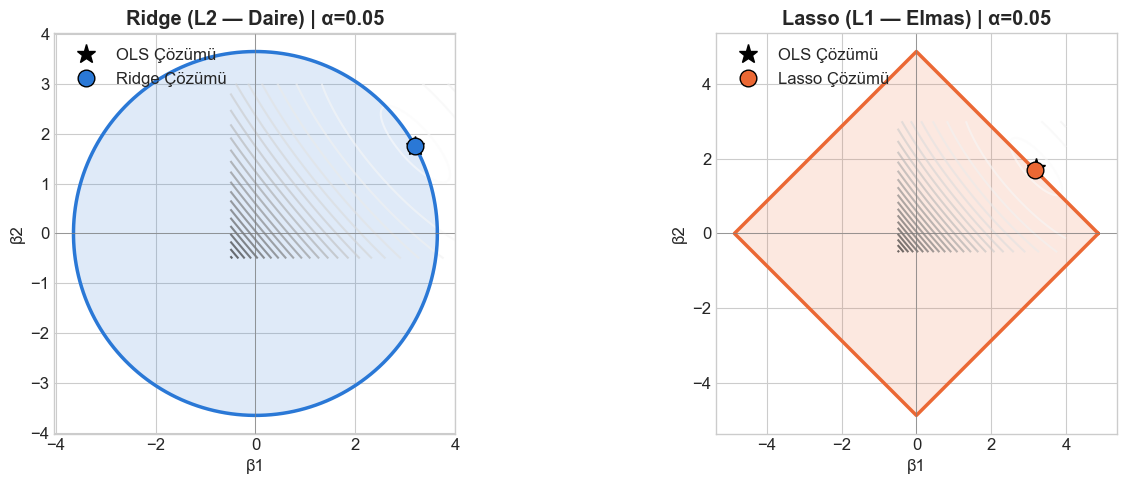

--- Alpha = 0.1 ---
Ridge çözümü: β1=3.189, β2=1.758
Lasso çözümü: β1=3.148, β2=1.633



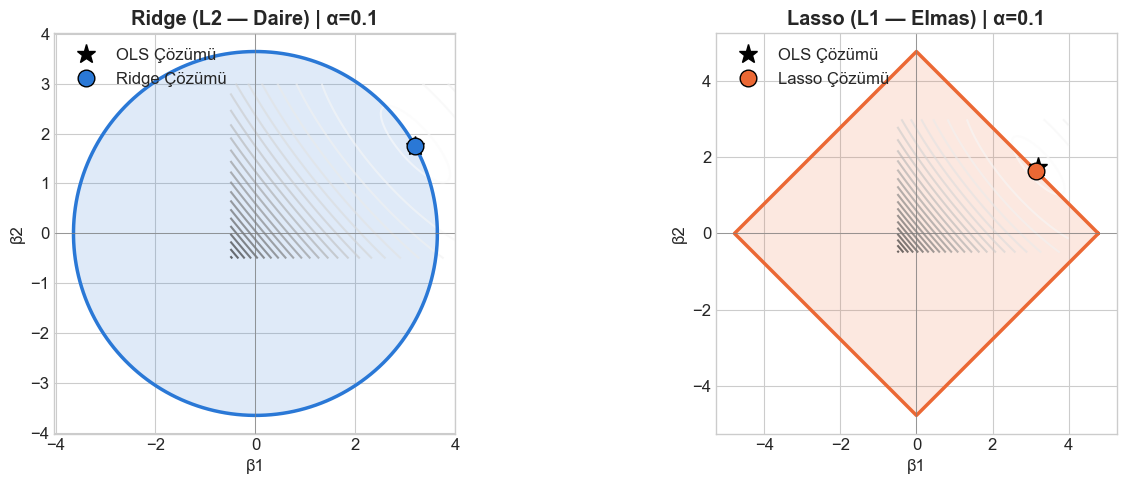

--- Alpha = 1 ---
Ridge çözümü: β1=3.163, β2=1.767
Lasso çözümü: β1=2.753, β2=0.523



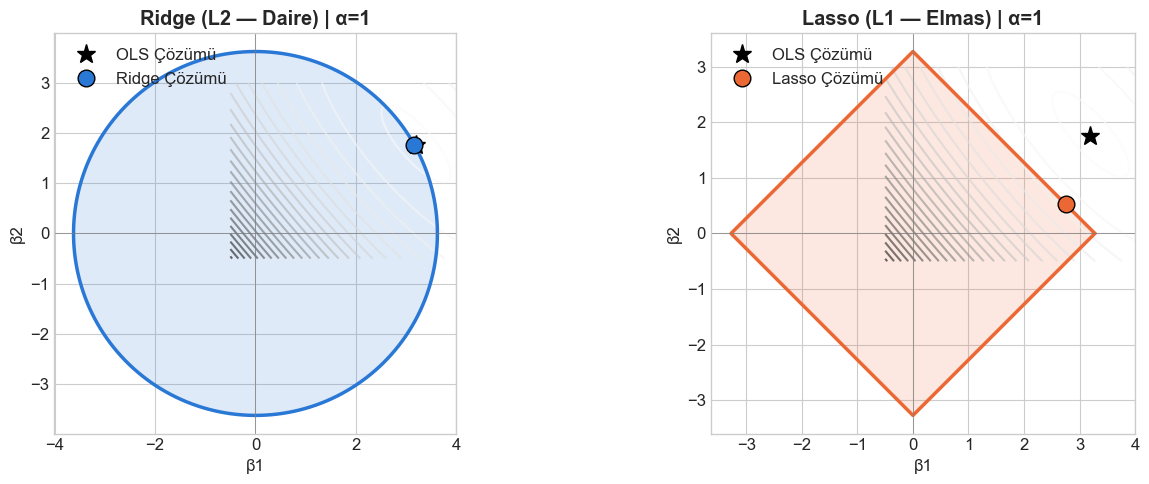

--- Alpha = 5 ---
Ridge çözümü: β1=3.062, β2=1.797
Lasso çözümü: β1=0.000, β2=0.000 <- β2 TAM SIFIRLANARAK ÖZELLİK ELENDİ!



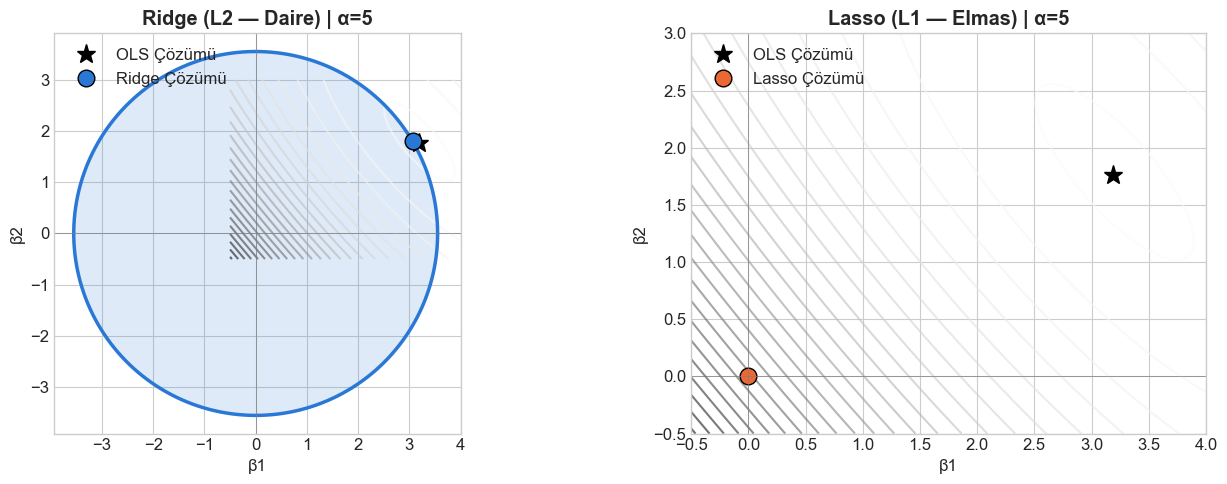

--- Alpha = 10 ---
Ridge çözümü: β1=2.955, β2=1.817
Lasso çözümü: β1=0.000, β2=0.000 <- β2 TAM SIFIRLANARAK ÖZELLİK ELENDİ!



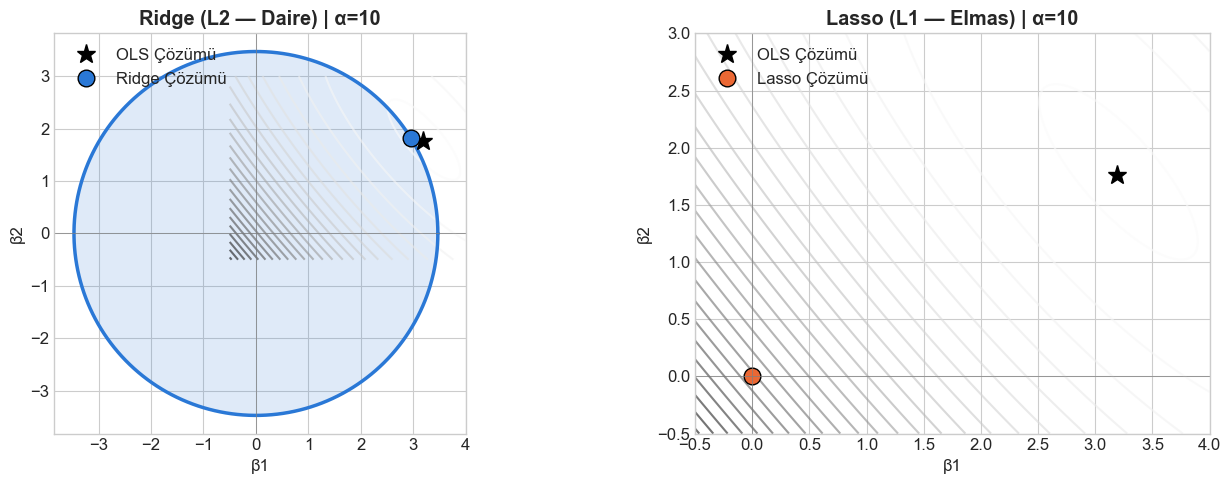

--- Alpha = 20 ---
Ridge çözümü: β1=2.780, β2=1.822
Lasso çözümü: β1=0.000, β2=0.000 <- β2 TAM SIFIRLANARAK ÖZELLİK ELENDİ!



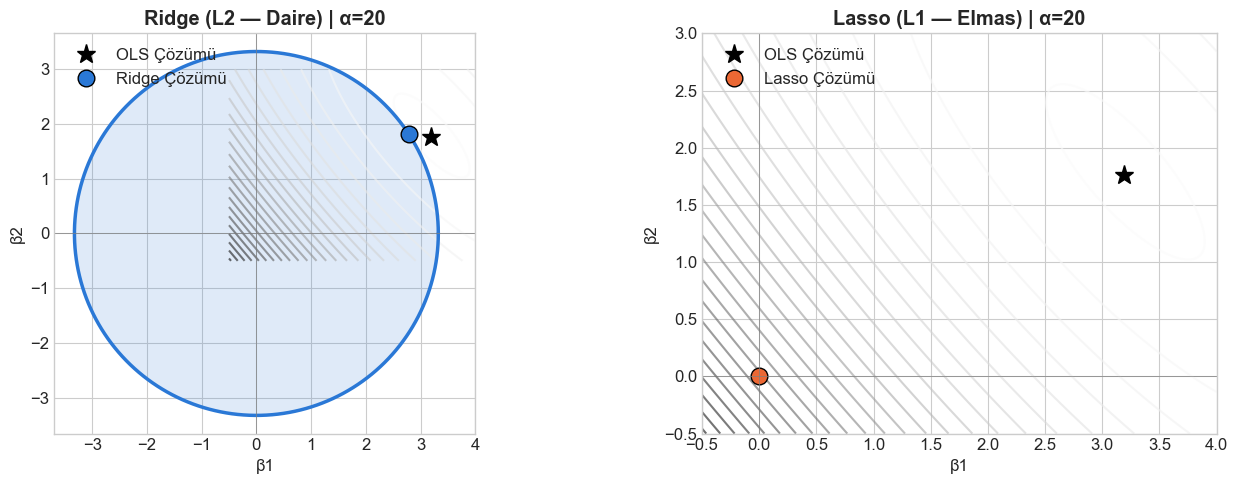

--- Alpha = 50 ---
Ridge çözümü: β1=2.414, β2=1.735
Lasso çözümü: β1=0.000, β2=0.000 <- β2 TAM SIFIRLANARAK ÖZELLİK ELENDİ!



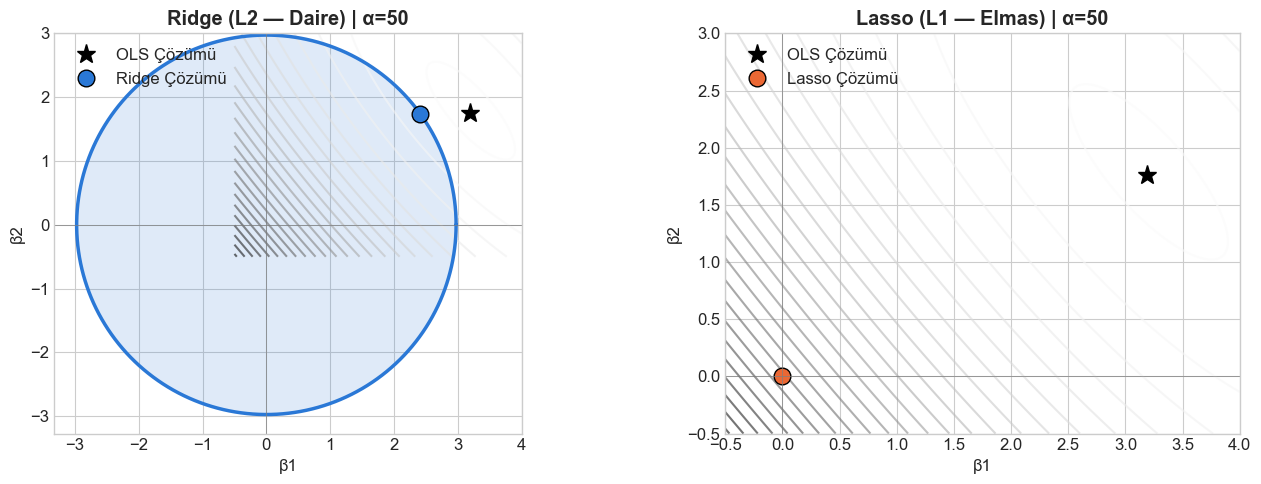

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso

print("\n ==== Egzersiz 4: Alpha Değeri Değiştirerek Ridge ve Lasso'ya Göre OLS'ye Yaklaşma ====")

# Basit, 2 özellikli, kasıtlı olarak ilişkili (multicollinear) sentetik veri
rng = np.random.default_rng(7)
n = 200
X1 = rng.normal(0, 1, n)
X2 = 0.7 * X1 + rng.normal(0, 0.5, n)  # X2, X1 ile ilişkili
y_sentetik = 3 * X1 + 2 * X2 + rng.normal(0, 1, n)
X_sentetik = np.column_stack([X1, X2])

# OLS Çözümü
ols_2d = LinearRegression().fit(X_sentetik, y_sentetik)
print(f"OLS çözümü (kısıtsız 'en iyi' nokta): β1={ols_2d.coef_[0]:.3f}, β2={ols_2d.coef_[1]:.3f}\n")

# HIZLI LOSS HESABI (Döngülerden kurtularak sadece 1 kere hesaplıyoruz)
b1_araligi = np.linspace(-0.5, 4, 200)
b2_araligi = np.linspace(-0.5, 3, 200)
B1, B2 = np.meshgrid(b1_araligi, b2_araligi)

# Vektörize edilmiş hızlı Loss hesabı (Hata Kareler Toplamı)
# Hepsini tek seferde hesaplamak için boyutları uyduruyoruz
X1_mesh = X1[:, np.newaxis, np.newaxis]
X2_mesh = X2[:, np.newaxis, np.newaxis]
y_mesh = y_sentetik[:, np.newaxis, np.newaxis]
tahminler = B1[np.newaxis, :, :] * X1_mesh + B2[np.newaxis, :, :] * X2_mesh
Loss = np.sum((y_mesh - tahminler) ** 2, axis=0)

# Farklı Alpha değerleri için Ridge ve Lasso modellerini çalıştırma ve çizme
for a in [0.05 ,0.1, 1, 5, 10, 20, 50]:
    ridge_2d = Ridge(alpha=a).fit(X_sentetik, y_sentetik)
    lasso_2d = Lasso(alpha=a).fit(X_sentetik, y_sentetik)

    print(f"--- Alpha = {a} ---")
    print(f"Ridge çözümü: β1={ridge_2d.coef_[0]:.3f}, β2={ridge_2d.coef_[1]:.3f}")
    
    #Lasso'nun tam sıfırlama durumunu kontrol eden dinamik metin
    sifirlama_metni = " <- β2 TAM SIFIRLANARAK ÖZELLİK ELENDİ!" if np.isclose(lasso_2d.coef_[1], 0, atol=1e-3) else ""
    print(f"Lasso çözümü: β1={lasso_2d.coef_[0]:.3f}, β2={lasso_2d.coef_[1]:.3f}{sifirlama_metni}\n")

    # Her alpha değeri için yan yana 2 grafiklik (1 satır, 2 sütun) figür oluşturuyoruz
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- RIDGE ÇİZİMİ (Sol Grafik) ---
    ax_ridge = axes[0]
    ax_ridge.contour(B1, B2, Loss, levels=25, cmap='Greys', alpha=0.6)
    
    # L2 Normu (Daire) Çizimi
    r_cozum = ridge_2d.coef_
    yaricap = np.linalg.norm(r_cozum) # L2 Normu hesaplama (Vektör Uzunluğu)
    aci = np.linspace(0, 2 * np.pi, 200)
    ax_ridge.plot(yaricap * np.cos(aci), yaricap * np.sin(aci), color='#2a78d6', linewidth=2.5)
    ax_ridge.fill(yaricap * np.cos(aci), yaricap * np.sin(aci), color='#2a78d6', alpha=0.15)
    
    ax_ridge.plot(*ols_2d.coef_, 'k*', markersize=14, label='OLS Çözümü')
    ax_ridge.plot(*r_cozum, 'o', color='#2a78d6', markersize=12, markeredgecolor='black', label='Ridge Çözümü')
    ax_ridge.axhline(0, color='gray', linewidth=0.5); ax_ridge.axvline(0, color='gray', linewidth=0.5)
    ax_ridge.set_title(f"Ridge (L2 — Daire) | α={a}", fontweight='bold')
    ax_ridge.set_xlabel('β1'); ax_ridge.set_ylabel('β2')
    ax_ridge.legend(loc='upper left')
    ax_ridge.set_aspect('equal')

    # --- LASSO ÇİZİMİ (Sağ Grafik) ---
    ax_lasso = axes[1]
    ax_lasso.contour(B1, B2, Loss, levels=25, cmap='Greys', alpha=0.6)
    
    # L1 Normu (Elmas / Diamond) Çizimi
    l_cozum = lasso_2d.coef_
    t = np.abs(l_cozum).sum() # L1 Normu hesaplama (Mutlak Değer Toplamı)
    elmas_x = [t, 0, -t, 0, t]
    elmas_y = [0, t, 0, -t, 0]
    ax_lasso.plot(elmas_x, elmas_y, color='#eb6834', linewidth=2.5)
    ax_lasso.fill(elmas_x, elmas_y, color='#eb6834', alpha=0.15)
    
    ax_lasso.plot(*ols_2d.coef_, 'k*', markersize=14, label='OLS Çözümü')
    ax_lasso.plot(*l_cozum, 'o', color='#eb6834', markersize=12, markeredgecolor='black', label='Lasso Çözümü')
    ax_lasso.axhline(0, color='gray', linewidth=0.5); ax_lasso.axvline(0, color='gray', linewidth=0.5)
    ax_lasso.set_title(f"Lasso (L1 — Elmas) | α={a}", fontweight='bold')
    ax_lasso.set_xlabel('β1'); ax_lasso.set_ylabel('β2')
    ax_lasso.legend(loc='upper left')
    ax_lasso.set_aspect('equal')

    plt.tight_layout()
    plt.show()


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [`probability-lab` 08 — MLE/MAP](../../Probability-lab/08_inference/) | Ridge=MAP bağlantısı | Bu notebook'un olasılıksal öncülü |
| [ISLP (Python)](https://www.statlearning.com) | Ch. 6 | Ridge/Lasso'nun istatistiksel öğrenme bağlamı |
| [3Blue1Brown — Essence of Linear Algebra](https://www.3blue1brown.com/topics/linear-algebra) | — | Genel norm/vektör sezgisi |
| [scikit-learn Ridge/Lasso Dokümantasyonu](https://scikit-learn.org/stable/modules/linear_model.html#ridge-regression-and-classification) | Kütüphane | Bu notebook'ta kullanılan araçlar |
| [Used Car Price Prediction Dataset](https://www.kaggle.com/datasets/asinow/car-price-dataset) | Veri | used_cars.csv kaynağı |